<a href="https://colab.research.google.com/github/sanjanascorner/PyTorch-and-DeepLearning/blob/main/ResNet18.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
from torch.utils.data import DataLoader
from torch.utils.data import Dataset

In [5]:
from torch.utils.data import random_split

transform_train=transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32,padding=4),
    transforms.ToTensor(),
    transforms.Normalize((0.4914,0.4822,0.4465),
                         (0.2023,0.1994,0.2010))
])
transform_test=transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4919,0.4822,0.4465),
                          (0.2023,0.1994,0.2010))
])

trainset=torchvision.datasets.CIFAR10(root='./data',train=True,
                                      download=True,transform=transform_train)
train_size = int(0.8 * len(trainset))
val_size = len(trainset) - train_size

trainset, valset = random_split(trainset, [train_size, val_size])

trainloader=DataLoader(trainset,batch_size=128,shuffle=True,num_workers=2)
valloader=DataLoader(valset,batch_size=100,shuffle=False,num_workers=2)

testset=torchvision.datasets.CIFAR10(root='./data',train=False,download=True,transform=transform_test)
testloader=DataLoader(testset,batch_size=100,shuffle=False,num_workers=2)

100%|██████████| 170M/170M [39:04<00:00, 72.7kB/s]


In [6]:
classes = ('plane','car','bird','cat','deer','dog','frog','horse','ship','truck')


In [7]:
class BasicBlock(nn.Module):
  def __init__(self,in_channels,out_channels,stride=1):
    super(BasicBlock,self).__init__()
    self.conv1=nn.Conv2d(in_channels,out_channels,kernel_size=3,stride=stride,padding=1,bias=False)
    self.bn1=nn.BatchNorm2d(out_channels)
    self.relu=nn.ReLU()
    self.conv2=nn.Conv2d(out_channels,out_channels,kernel_size=3,stride=1,padding=1,bias=False)
    self.bn2=nn.BatchNorm2d(out_channels)
    self.shortcut=nn.Sequential()
    if stride!=1 or in_channels != out_channels:
       self.shortcut=nn.Sequential(
            nn.Conv2d(in_channels,out_channels,kernel_size=1,stride=stride,bias=False),
            nn.BatchNorm2d(out_channels)
       )
  def forward(self,x):
     out=self.conv1(x)
     out=self.bn1(out)
     out=self.relu(out)
     out=self.conv2(out)
     out=self.bn2(out)
     out+=self.shortcut(x)
     out=self.relu(out)
     return out

In [8]:
class ResNet18(nn.Module):
  def __init__(self, num_classes=10):
    super(ResNet18,self).__init__()
    self.in_channels=64
    self.conv1=nn.Conv2d(3,64,kernel_size=3,stride=1,bias=False)
    self.bn1=nn.BatchNorm2d(64)
    self.relu=nn.ReLU(inplace=True)
    self.layer1=self._make_layer(BasicBlock,64,2,stride=1)
    self.layer2=self._make_layer(BasicBlock,128,2,stride=2)
    self.layer3=self._make_layer(BasicBlock,256,2,stride=2)
    self.layer4=self._make_layer(BasicBlock,512,2,stride=2)
    self.avgpool=nn.AdaptiveAvgPool2d((1,1))
    self.fc=nn.Linear(512,num_classes)

  def _make_layer(self,block,out_channels,num_blocks,stride):
      strides=[stride] + [1]*(num_blocks-1)
      layers=[]
      for stride in strides:
          layers.append(block(self.in_channels,out_channels,stride))
          self.in_channels=out_channels
      return nn.Sequential(*layers)
  def forward(self,x):
      out=self.conv1(x)
      out=self.bn1(out)
      out=self.relu(out)
      out=self.layer1(out)
      out=self.layer2(out)
      out=self.layer3(out)
      out=self.layer4(out)
      out=self.avgpool(out)
      out=out.view(out.size(0),-1)
      out=self.fc(out)
      return out

device = 'cuda' if torch.cuda.is_available() else 'cpu'
model=ResNet18().to(device)
print(model)

ResNet18(
  (conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU()
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (shortcut): Sequential()
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU()
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    

In [10]:
from torch.optim import optimizer
criterion = nn.CrossEntropyLoss()
optimizer= optim.SGD(model.parameters(),lr=0.1,momentum=0.9,weight_decay=5e-4)
scheduler=optim.lr_scheduler.StepLR(optimizer,step_size=30,gamma=0.1)

Training Loop

In [11]:
num_epochs=10
train_losses,train_accuracies,val_losses,val_accuracies=[],[],[],[]
for epoch in range(num_epochs):

    model.train()
    running_loss=0.0
    correct,total=0,0
    for inputs,labels in trainloader:
        inputs,labels=inputs.to(device),labels.to(device)
        optimizer.zero_grad()
        outputs=model(inputs)
        loss=criterion(outputs,labels)
        loss.backward()
        optimizer.step()
        running_loss+=loss.item() * inputs.size(0)
        _,predicted=outputs.max(1)
        total+=labels.size(0)
        correct+=predicted.eq(labels).sum().item()
    train_loss=running_loss/len(trainloader.dataset)
    train_acc=100.*correct/total
    train_losses.append(train_loss)
    train_accuracies.append(train_acc)

    model.eval()
    running_val_loss = 0.0
    correct,total=0,0
    with torch.no_grad():
         for inputs,labels in valloader:
             inputs,labels = inputs.to(device),labels.to(device)
             outputs=model(inputs)
             loss=criterion(outputs,labels)
             running_val_loss+=loss.item() * inputs.size(0)
             _,predicted=outputs.max(1)
             total+=labels.size(0)
             correct+=predicted.eq(labels).sum().item()
    val_loss = running_val_loss / len(valloader.dataset)
    val_acc=100.*correct/total
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)
    scheduler.step()
    print(f'Epoch [{epoch+1}/{num_epochs}] Train Loss: {train_loss:.4f} Train Acc: {train_acc:.2f}%  Validation Loss: {val_loss:.4f} Validation Acc: {val_acc:.2f}%')


Epoch [1/10] Train Loss: 2.1026 Train Acc: 26.32%  Validation Loss: 1.6740 Validation Acc: 38.25%
Epoch [2/10] Train Loss: 1.5706 Train Acc: 41.66%  Validation Loss: 1.4478 Validation Acc: 47.20%
Epoch [3/10] Train Loss: 1.3604 Train Acc: 50.31%  Validation Loss: 1.3772 Validation Acc: 50.86%
Epoch [4/10] Train Loss: 1.1793 Train Acc: 57.41%  Validation Loss: 1.1995 Validation Acc: 57.03%
Epoch [5/10] Train Loss: 1.0291 Train Acc: 63.37%  Validation Loss: 1.1424 Validation Acc: 61.10%
Epoch [6/10] Train Loss: 0.9253 Train Acc: 67.12%  Validation Loss: 1.1246 Validation Acc: 60.79%
Epoch [7/10] Train Loss: 0.8232 Train Acc: 71.03%  Validation Loss: 0.8735 Validation Acc: 69.85%
Epoch [8/10] Train Loss: 0.7293 Train Acc: 74.76%  Validation Loss: 0.7842 Validation Acc: 72.86%
Epoch [9/10] Train Loss: 0.6611 Train Acc: 76.97%  Validation Loss: 0.8001 Validation Acc: 72.85%
Epoch [10/10] Train Loss: 0.6148 Train Acc: 78.73%  Validation Loss: 0.6446 Validation Acc: 77.85%


In [12]:
model.eval()
y_true = []
y_pred = []
images = []

with torch.no_grad():
    for inputs, labels in testloader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs, 1)
        images.append(inputs.cpu())
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())
images = torch.cat(images, dim=0)

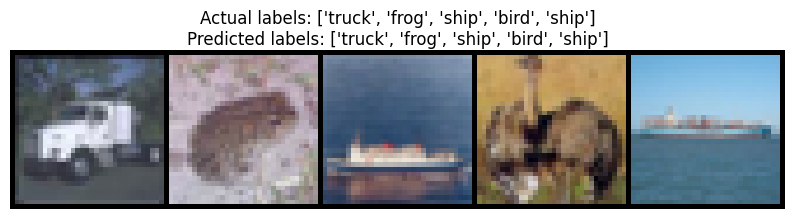

In [22]:
num_images = 5
random_index = np.random.choice(len(images), num_images, replace=False)
y_true_selected = [classes[y_true[idx]] for idx in random_index]
y_pred_selected = [classes[y_pred[idx]] for idx in random_index]
title = f"Actual labels: {y_true_selected}\nPredicted labels: {y_pred_selected}"
plt.figure(figsize=(10, 10))
plt.imshow(np.transpose(torchvision.utils.make_grid(
    images[random_index].cpu(), normalize=True, padding=1).numpy(), (1, 2, 0)))
plt.title(title, wrap=True)
plt.axis("off")
plt.show()

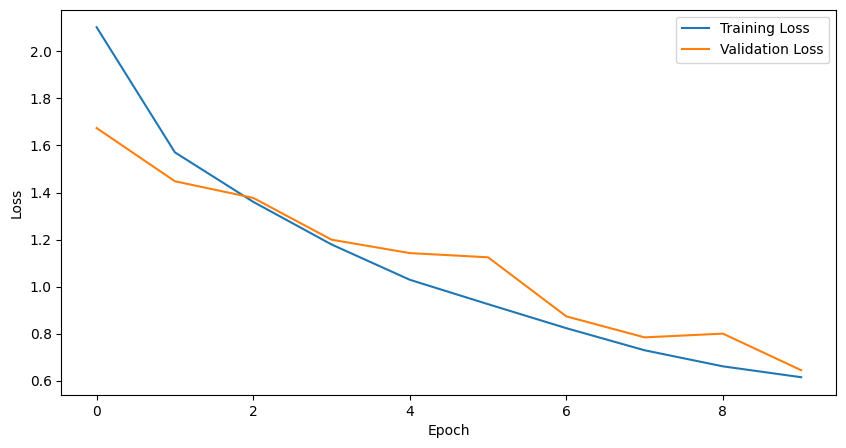

In [14]:
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

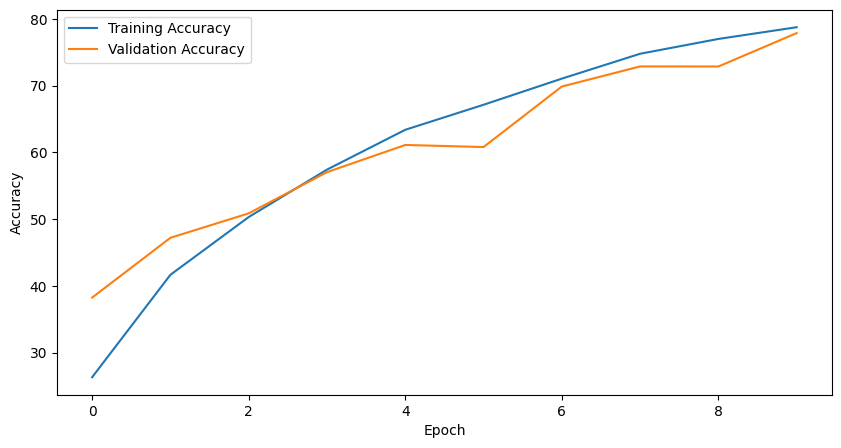

In [15]:
plt.figure(figsize=(10, 5))
plt.plot(train_accuracies, label='Training Accuracy')
plt.plot(val_accuracies, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()